# COMP6010 C2 — Final review and corrected reflections
**Sayuru Bopitiya · 24071158**

This restart-ready notebook restores your **192 completed second-pass ratings**, preserves the original evidence, reproduces both-pass analyses and supplies corrected reflection drafts. CPU is sufficient. No retraining, generation or rescoring is needed.

**Use Runtime → Run all.** Mount Drive when prompted. If the previous results are not found, upload **cat_eval64_reassessment_v1_results (1).zip**. After all cells finish:

1. Go to **Cell 4**, inspect the displayed table and count its rows yourself.
2. Review/adapt the six prefilled reflection drafts, enter your count, tick the confirmation and click **Save reviewed reflection**.
3. Rerun **Cell 5** to download the completed ZIP. Save this executed notebook too.

A first Run all may print `INCOMPLETE` until you review and save the reflection. It is not an error. All work goes into a separate folder, `cat_eval64_final_v1`; the old run remains unchanged.

The reassessment followed AI feedback and exposure to earlier results. It does not restore the original blinding. Both rating passes remain in the output. “Final review” is the name of this workflow, not a guarantee that the whole assignment is submission-ready.


## Cell 1 — Setup and mount Drive


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import base64, hashlib, io, json, os, platform, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from IPython.display import display, clear_output
try:
    import ipywidgets as widgets
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ipywidgets'])
    import ipywidgets as widgets

SAVE_TO_DRIVE = True
RUN_NAME = 'cat_eval64_final_v1'
if SAVE_TO_DRIVE:
    from google.colab import drive, output
    drive.mount('/content/drive')
    output.enable_custom_widget_manager()
    BASE = Path('/content/drive/MyDrive/COMP6010')
else:
    BASE = Path.cwd() / 'COMP6010'
RUN = BASE / RUN_NAME
RUN.mkdir(parents=True, exist_ok=True)
SOURCE = RUN / 'source_snapshot'
SOURCE.mkdir(exist_ok=True)
CONFIGS = [('early50_steps50',50,50),('late250_steps50',250,50),('late250_steps20',250,20)]
SEEDS = list(range(19001,19065))
SHUFFLE_SEED = 601032
BOOTSTRAP_SEED = 601029
BOOTSTRAP_REPEATS = 20000
EXPECTED_FIRST_RATINGS = '4ef13f831686401e131fb29b0c93fb96ae5c54dc30bec5705ed3ab36876da10d'
VERSIONS = {'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__}
def utc_now(): return datetime.now(timezone.utc).isoformat()
def digest(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def save_json(path,obj):
    path=Path(path);tmp=path.with_suffix(path.suffix+'.tmp')
    tmp.write_text(json.dumps(obj,indent=2),encoding='utf-8');os.replace(tmp,path)
def save_csv(path,frame):
    path=Path(path);tmp=path.with_suffix(path.suffix+'.tmp')
    frame.to_csv(tmp,index=False);os.replace(tmp,path)
print('Separate final-review folder:',RUN)


Mounted at /content/drive
Separate final-review folder: /content/drive/MyDrive/COMP6010/cat_eval64_final_v1


## Cell 2 — Restore completed work safely
This checks the completed reassessment ZIP in your Drive folder, then the existing reassessment folder. If neither is available, upload your saved reassessment results ZIP. It must contain the 192 ratings already reviewed in this conversation.

The entire input ZIP is preserved. Earlier reflections and analysis are retained under `history_before_corrections/`; corrected reflections are only saved after your review. On later runs, the final-review folder is reused without resetting your saved work.


In [2]:
RESTORE_ZIP = ''  # Optional full path to your completed reassessment ZIP
EXPECTED_SECOND_RATINGS = 'bb0c304f61f97dc94f86ffe87a007f26d02ac3d659cdbe6249d4ffd429088c82'
marker_path=RUN/'restore_provenance.json'
input_zip_path=RUN/'input_reassessment_results.zip'
required=['second_pass_ratings.csv','review_key_DO_NOT_OPEN_UNTIL_SCORED.csv','reassessment_protocol.json',
          'source_snapshot/human_ratings.csv','source_snapshot/configuration_key_DO_NOT_OPEN_UNTIL_SCORED.csv',
          'source_snapshot/protocol.json','source_snapshot/generation_complete.json','source_snapshot/timing_repeats.csv',
          'source_snapshot/original_scored_results.zip']+[f'source_snapshot/raw_arrays/{n}.npy' for n,_,_ in CONFIGS]
def validate_input(data):
    with zipfile.ZipFile(io.BytesIO(data)) as z:
        if sum(i.file_size for i in z.infolist())>50*1024*1024: raise ValueError('Unexpectedly large results archive.')
        if z.testzip() is not None: raise ValueError('Results ZIP integrity check failed.')
        names=z.namelist()
        if len(names)!=len(set(names)) or not set(required).issubset(names): raise ValueError('Missing or duplicate result files.')
        for name in names:
            p=Path(name)
            if p.is_absolute() or '..' in p.parts or chr(92) in name: raise ValueError('Unsafe ZIP path.')
        if hashlib.sha256(z.read('second_pass_ratings.csv')).hexdigest()!=EXPECTED_SECOND_RATINGS:
            raise ValueError('This is not the completed 192-rating reassessment reviewed in this conversation.')
        if hashlib.sha256(z.read('source_snapshot/human_ratings.csv')).hexdigest()!=EXPECTED_FIRST_RATINGS:
            raise ValueError('Original ratings differ from the reviewed evidence.')
        protocol=json.loads(z.read('reassessment_protocol.json'))
        for field,name in [('review_key_sha256','review_key_DO_NOT_OPEN_UNTIL_SCORED.csv'),
                           ('source_zip_sha256','source_snapshot/original_scored_results.zip')]:
            if hashlib.sha256(z.read(name)).hexdigest()!=protocol[field]:raise ValueError('Reassessment provenance mismatch.')
        gen=json.loads(z.read('source_snapshot/generation_complete.json'))
        if hashlib.sha256(z.read('source_snapshot/protocol.json')).hexdigest()!=gen['protocol_sha256']:raise ValueError('Generation protocol mismatch.')
        for n,_,_ in CONFIGS:
            if hashlib.sha256(z.read(f'source_snapshot/raw_arrays/{n}.npy')).hexdigest()!=gen['array_sha256'][n]:raise ValueError('Generated image mismatch.')
        return {n:z.read(n) for n in names if not n.endswith('/')}
if marker_path.exists():
    marker=json.loads(marker_path.read_text())
    assert input_zip_path.exists() and digest(input_zip_path)==marker['input_archive_sha256']
    validate_input(input_zip_path.read_bytes())
    print('Reusing the saved final-review folder. Ratings and reviewed reflections are preserved.')
else:
    data=None
    candidate=Path(RESTORE_ZIP) if RESTORE_ZIP.strip() else BASE/'cat_eval64_reassessment_v1_results.zip'
    if candidate.is_file():
        try:
            trial=candidate.read_bytes();validate_input(trial);data=trial
        except (ValueError,KeyError,zipfile.BadZipFile) as e:print('Drive ZIP not accepted:',e)
    if data is None and not RESTORE_ZIP.strip():
        old_run=BASE/'cat_eval64_reassessment_v1'
        if (old_run/'second_pass_ratings.csv').is_file():
            try:
                buffer=io.BytesIO()
                with zipfile.ZipFile(buffer,'w',zipfile.ZIP_DEFLATED) as z:
                    for p in sorted(old_run.rglob('*')):
                        if p.is_file() and not p.name.endswith('.tmp'):z.write(p,p.relative_to(old_run))
                trial=buffer.getvalue();validate_input(trial);data=trial
            except (ValueError,KeyError,zipfile.BadZipFile) as e:print('Previous folder not accepted:',e)
    if data is None:
        from google.colab import files
        print('Upload cat_eval64_reassessment_v1_results (1).zip now.')
        uploaded=files.upload();archives=[v for k,v in uploaded.items() if k.lower().endswith('.zip')]
        if len(archives)!=1:raise ValueError('Upload exactly one completed reassessment ZIP.')
        data=archives[0]
    restored=validate_input(data)
    # Any existing conflicting partial restore is rejected, not overwritten.
    planned={}
    for name,content in restored.items():
        if name in ['student_reflection.json','analysis_provenance.json','export_status.json','README.txt']:
            name='history_before_corrections/'+name
        dest=RUN/name
        if dest.exists() and dest.read_bytes()!=content:raise ValueError('Conflicting existing restore file: '+name)
        planned[dest]=content
    if input_zip_path.exists() and input_zip_path.read_bytes()!=data:raise ValueError('Different input ZIP already present.')
    input_zip_path.write_bytes(data)
    for dest,content in planned.items():
        dest.parent.mkdir(parents=True,exist_ok=True)
        if not dest.exists():dest.write_bytes(content)
    save_json(marker_path,{'restored_utc':utc_now(),'input_archive_sha256':digest(input_zip_path),
                          'second_ratings_sha256':EXPECTED_SECOND_RATINGS,'purpose':'Correct reflection facts; preserve both rating passes'})
    print('Completed reassessment restored into a separate final-review folder.')
ratings_path=RUN/'second_pass_ratings.csv'
key_path=RUN/'review_key_DO_NOT_OPEN_UNTIL_SCORED.csv'
protocol_path=RUN/'reassessment_protocol.json'
snapshot_zip=SOURCE/'original_scored_results.zip'
assert digest(ratings_path)==EXPECTED_SECOND_RATINGS and digest(SOURCE/'human_ratings.csv')==EXPECTED_FIRST_RATINGS
key=pd.read_csv(key_path)
first=pd.read_csv(SOURCE/'human_ratings.csv',keep_default_na=False)
original_key=pd.read_csv(SOURCE/'configuration_key_DO_NOT_OPEN_UNTIL_SCORED.csv')
protocol=json.loads(protocol_path.read_text())
assert digest(key_path)==protocol['review_key_sha256']
assert len(key)==192 and key.review_id.is_unique and key.original_image_id.is_unique
assert key.original_image_id.tolist()==original_key.iloc[np.random.default_rng(SHUFFLE_SEED).permutation(192)].image_id.tolist()
arrays={n:np.load(SOURCE/f'raw_arrays/{n}.npy',allow_pickle=False) for n,_,_ in CONFIGS}
meta=json.loads((SOURCE/'generation_complete.json').read_text())
assert all(a.shape==(64,1,28,28) and np.isfinite(a).all() for a in arrays.values())
for n,_,_ in CONFIGS:assert digest(SOURCE/f'raw_arrays/{n}.npy')==meta['array_sha256'][n]
print('All 192 second-pass ratings and original image hashes verified. No scoring or training is needed.')


Reusing the saved final-review folder. Ratings and reviewed reflections are preserved.
All 192 second-pass ratings and original image hashes verified. No scoring or training is needed.


## Cell 3 — Reproduce both-pass results
This recomputes counts, Wilson intervals, paired bootstrap comparisons and rating agreement. The confidence intervals condition on the sampled seeds, trained checkpoints and one evaluator. They do not include uncertainty from how the evaluator interprets the rubric.

Original A100 timings are reused, not benchmarked again. The original and reassessment outcomes are both retained. Rerunning this analysis may require saving the reflection again because its provenance changes.


In [3]:
def load_second_pass():
    frame=pd.read_csv(ratings_path,keep_default_na=False)
    if len(frame)!=192 or not frame.review_id.is_unique or set(frame.review_id)!=set(key.review_id):
        raise ValueError('Second-pass IDs are missing, duplicated or unexpected.')
    scores=pd.to_numeric(frame.cat_score,errors='coerce')
    if scores.isna().any(): raise ValueError(f'{scores.notna().sum()}/192 scored. Finish Section 4 first.')
    if not scores.isin([0,1,2]).all(): raise ValueError('Scores must be 0, 1 or 2.')
    if frame.rater.str.strip().eq('').any(): raise ValueError('Missing rater name.')
    times=pd.to_datetime(frame.rated_utc,utc=True,errors='coerce')
    if times.isna().any(): raise ValueError('Invalid rating timestamp.')
    protocol=json.loads(protocol_path.read_text())
    if (times<pd.Timestamp(protocol['recorded_utc'])).any(): raise ValueError('Rating precedes reassessment protocol.')
    assert protocol['review_key_sha256']==digest(key_path)
    assert digest(SOURCE/'human_ratings.csv')==EXPECTED_FIRST_RATINGS
    frame['cat_score']=scores.astype(int)
    return frame.merge(key,on='review_id',validate='one_to_one')
def paired_difference(a,b,seed=BOOTSTRAP_SEED,repeats=BOOTSTRAP_REPEATS):
    a=np.asarray(a,dtype=float);b=np.asarray(b,dtype=float)
    if a.shape!=b.shape or a.ndim!=1 or not len(a):raise ValueError('Matched nonempty vectors required.')
    d=a-b
    indices=np.random.default_rng(seed).integers(0,len(d),size=(repeats,len(d)))
    resampled=d[indices].mean(axis=1)
    lo,hi=np.quantile(resampled,[0.025,0.975])
    return {'difference':float(d.mean()),'ci95_low':float(lo),'ci95_high':float(hi),
            'degenerate_bootstrap':bool(np.ptp(d)==0)}

def analyse_scored(merged):
    summaries=[]
    for name,epoch,steps in CONFIGS:
        g=merged[merged.configuration==name];assert len(g)==64
        k=int((g.cat_score==2).sum());ci=binomtest(k,len(g)).proportion_ci(method='wilson')
        summaries.append({'configuration':name,'epoch':epoch,'steps':steps,'n':len(g),
            'recognisable_count':k,'recognisable_fraction':k/len(g),'wilson95_low':ci.low,'wilson95_high':ci.high,
            'mean_score':g.cat_score.mean()})
    wide=merged.pivot(index='seed',columns='configuration',values='cat_score').sort_index()
    assert wide.index.tolist()==SEEDS and not wide.isna().any().any()
    comparisons=[];per_seed=[]
    for label,a,b in [('training','late250_steps50','early50_steps50'),('inference','late250_steps20','late250_steps50')]:
        av=wide[a].to_numpy();bv=wide[b].to_numpy()
        for metric,x,y in [('recognisable_fraction',(av==2).astype(float),(bv==2).astype(float)),('mean_score',av,bv)]:
            comparisons.append({'comparison':label,'a':a,'b':b,'metric':metric,
                                **paired_difference(x,y),
                                'improved_seeds':int((x>y).sum()),'tied_seeds':int((x==y).sum()),'worsened_seeds':int((x<y).sum())})
        for seed,x,y in zip(SEEDS,av,bv):per_seed.append({'comparison':label,'seed':seed,'a_score':int(x),'b_score':int(y),'difference':int(x-y)})
    return pd.DataFrame(summaries),pd.DataFrame(comparisons),pd.DataFrame(per_seed)


def run_analysis():
    second=load_second_pass()
    original=first.merge(original_key,on='image_id',validate='one_to_one')
    summaries=[];contrasts=[]
    for label,frame in [('original',original),('reassessment',second)]:
        summary,comparisons,per_seed=analyse_scored(frame)
        summary.insert(0,'pass',label);comparisons.insert(0,'pass',label)
        summaries.append(summary);contrasts.append(comparisons)
        save_csv(RUN/f'{label}_paired_seed_scores.csv',per_seed)
    summary=pd.concat(summaries,ignore_index=True);comparisons=pd.concat(contrasts,ignore_index=True)
    audit=second.merge(first[['image_id','cat_score','notes']].rename(columns={'image_id':'original_image_id','cat_score':'first_score','notes':'first_note'}),on='original_image_id',validate='one_to_one').rename(columns={'cat_score':'second_score'})
    audit['score_change']=audit.second_score-audit.first_score
    matrix=pd.crosstab(audit.first_score,audit.second_score).reindex(index=[0,1,2],columns=[0,1,2],fill_value=0)
    reliability={'n_images':192,'exact_agreement_fraction':float((audit.first_score==audit.second_score).mean()),
      'increased':int((audit.score_change>0).sum()),'unchanged':int((audit.score_change==0).sum()),'decreased':int((audit.score_change<0).sum()),
      'mean_absolute_score_change':float(audit.score_change.abs().mean()),
      'became_recognisable':int(((audit.first_score!=2)&(audit.second_score==2)).sum()),
      'no_longer_recognisable':int(((audit.first_score==2)&(audit.second_score!=2)).sum()),
      'interpretation':'Descriptive within-rater agreement following rubric clarification and feedback; not independent accuracy or inter-rater reliability.'}
    save_csv(RUN/'both_passes_quality_summary.csv',summary)
    save_csv(RUN/'both_passes_paired_comparisons.csv',comparisons)
    save_csv(RUN/'rating_change_audit.csv',audit)
    save_csv(RUN/'agreement_matrix.csv',matrix.rename(columns={i:f'second_{i}' for i in [0,1,2]}).reset_index())
    save_json(RUN/'within_rater_agreement.json',reliability)
    timings=pd.read_csv(SOURCE/'timing_repeats.csv')
    timing_summary=timings.groupby('configuration').seconds_for_64.agg(['median','std','count']).reset_index()
    save_csv(RUN/'original_generation_timing_summary.csv',timing_summary)
    save_json(RUN/'analysis_provenance.json',{'analysed_utc':utc_now(),'second_ratings_sha256':digest(ratings_path),
      'first_ratings_sha256':digest(SOURCE/'human_ratings.csv'),'protocol_sha256':digest(protocol_path),
      'source_zip_sha256':digest(snapshot_zip),'review_key_sha256':digest(key_path),'versions':VERSIONS})
    print('Both passes — keep both in the report:');display(summary)
    print('Configuration differences, separately for each pass:');display(comparisons)
    print('Agreement table: rows = first pass, columns = second pass');display(matrix)
    print('Exact agreement:',f"{100*reliability['exact_agreement_fraction']:.1f}%")
    print('Increased / unchanged / decreased:',reliability['increased'],reliability['unchanged'],reliability['decreased'])
    print('Original generation timings (not new timings):');display(timing_summary)
    print('Inspect rating_change_audit.csv for individual decisions. Continue to Cell 4 to review the corrected reflection.')
    return summary,comparisons,audit
frame=pd.read_csv(ratings_path,keep_default_na=False)
if not protocol_path.exists() or pd.to_numeric(frame.cat_score,errors='coerce').isna().any():
    print('Analysis withheld. Restoration incomplete: check Cell 2.')
else:
    summary,comparisons,audit=run_analysis()


Both passes — keep both in the report:


,pass,configuration,epoch,steps,n,recognisable_count,recognisable_fraction,wilson95_low,wilson95_high,mean_score
0,original,early50_steps50,50,50,64,1,0.015625,0.002764,0.083341,0.359375
1,original,late250_steps50,250,50,64,3,0.046875,0.016069,0.128997,0.531250
2,original,late250_steps20,250,20,64,1,0.015625,0.002764,0.083341,0.484375
3,reassessment,early50_steps50,50,50,64,1,0.015625,0.002764,0.083341,0.625000
4,reassessment,late250_steps50,250,50,64,10,0.156250,0.087148,0.264281,0.859375
5,reassessment,late250_steps20,250,20,64,11,0.171875,0.098777,0.282132,0.921875


Configuration differences, separately for each pass:


,pass,comparison,a,b,metric,difference,ci95_low,ci95_high,degenerate_bootstrap,improved_seeds,tied_seeds,worsened_seeds
0,original,training,late250_steps50,early50_steps50,recognisable_fraction,0.031250,-0.031250,0.093750,False,3,60,1
1,original,training,late250_steps50,early50_steps50,mean_score,0.171875,0.000000,0.343750,False,21,32,11
2,original,inference,late250_steps20,late250_steps50,recognisable_fraction,-0.031250,-0.078125,0.000000,False,0,62,2
3,original,inference,late250_steps20,late250_steps50,mean_score,-0.046875,-0.171875,0.078125,False,7,47,10
4,reassessment,training,late250_steps50,early50_steps50,recognisable_fraction,0.140625,0.062500,0.234375,False,9,55,0
5,reassessment,training,late250_steps50,early50_steps50,mean_score,0.234375,0.062500,0.406250,False,19,38,7
6,reassessment,inference,late250_steps20,late250_steps50,recognisable_fraction,0.015625,-0.031250,0.078125,False,2,61,1
7,reassessment,inference,late250_steps20,late250_steps50,mean_score,0.062500,-0.031250,0.156250,False,7,54,3


Agreement table: rows = first pass, columns = second pass


second_score,0,1,2
first_score,,,
0,54,54,1
1,6,55,17
2,0,1,4


Exact agreement: 58.9%
Increased / unchanged / decreased: 72 113 7
Original generation timings (not new timings):


,configuration,median,std,count
0,early50_steps50,0.616756,0.010338,5
1,late250_steps20,0.248750,0.004470,5
2,late250_steps50,0.616164,0.003571,5


Inspect rating_change_audit.csv for individual decisions. Continue to Cell 4 to review the corrected reflection.


## Cell 4 — Check the count, review the corrected text, and save
The first table lists the records you should count yourself. Review the evidence and corrected drafts below. You may edit the text to reflect your own understanding. AI supplied these drafts; your review and check must be genuine.

Enter your manual row count and tick the confirmation **only after doing the check and reviewing all six fields**. Click **Save reviewed reflection**. This writes a new dated reflection and retains the earlier one in history. It does not change any rating, prediction or timing.

The independent-check draft uses “I” and is saved only after your explicit confirmation. A programmatic total by itself is not evidence that you personally performed the check.


Manually count the rows below:


,review_id,seed,second_score
0,REVIEW_045,19009,2
1,REVIEW_055,19020,2
2,REVIEW_067,19015,2
3,REVIEW_069,19059,2
4,REVIEW_098,19060,2
5,REVIEW_102,19001,2
6,REVIEW_121,19033,2
7,REVIEW_156,19053,2
8,REVIEW_167,19006,2
9,REVIEW_180,19028,2


Original timing evidence:


,configuration,median,std,count
0,early50_steps50,0.616756,0.010338,5
1,late250_steps20,0.248750,0.004470,5
2,late250_steps50,0.616164,0.003571,5


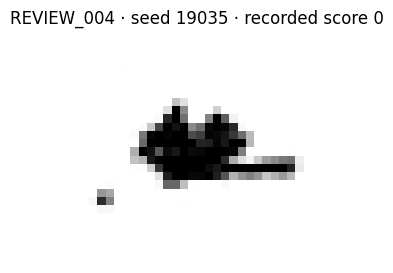

Original training prediction: I expect the 250-epoch model to produce slightly more recognisable cats than the 50-epoch model. The earlier results showed lower held-out loss but only a small visual improvement, so I expect some ambiguous drawings to remain in the new sample.
Original sampling prediction: I expect 20 Euler steps to generate images faster than 50 steps, with broadly similar recognisability but possibly less coherent detail in some drawings. I will check whether this holds across the new seeds.


In [4]:
def analysis_current():
    path=RUN/'analysis_provenance.json'
    if not path.exists() or not protocol_path.exists(): return False
    p=json.loads(path.read_text())
    return (p['second_ratings_sha256']==digest(ratings_path) and p['protocol_sha256']==digest(protocol_path)
            and p['first_ratings_sha256']==digest(SOURCE/'human_ratings.csv') and p['review_key_sha256']==digest(key_path))

check=pd.read_csv(RUN/'rating_change_audit.csv')
matching_rows=check.loc[(check.configuration=='late250_steps50') & (check.second_score==2),['review_id','seed','second_score']]
print('Manually count the rows below:');display(matching_rows.reset_index(drop=True))
assert matching_rows.review_id.tolist()==['REVIEW_045','REVIEW_055','REVIEW_067','REVIEW_069','REVIEW_098','REVIEW_102','REVIEW_121','REVIEW_156','REVIEW_167','REVIEW_180']
print('Original timing evidence:');display(pd.read_csv(RUN/'original_generation_timing_summary.csv'))
row=key[key.review_id=='REVIEW_004'].iloc[0]
fig,ax=plt.subplots(figsize=(3,3))
ax.imshow(np.clip((arrays[row.configuration][int(row.array_index),0]+1)/2,0,1),cmap='gray_r',vmin=0,vmax=1,interpolation='nearest')
ax.set_title('REVIEW_004 · seed 19035 · recorded score 0');ax.axis('off');plt.show();plt.close(fig)
original_protocol=json.loads((SOURCE/'protocol.json').read_text())
print('Original training prediction:',original_protocol['student_prediction_training'])
print('Original sampling prediction:',original_protocol['student_prediction_steps'])
reflection_labels={
 'training_prediction_vs_observation':'1. Training prediction versus observation',
 'steps_prediction_vs_observation':'2. Sampling prediction versus observation',
 'rating_consistency':'3. Rating consistency',
 'failure_or_limitation':'4. Failure or limitation',
 'independent_check_and_source':'5. Independent check — save only after personally checking',
 'next_decision':'6. Next decision'}
CORRECTED_DRAFTS = {'training_prediction_vs_observation': 'The original pass identified 3/64 recognisable outputs at 250 epochs versus 1/64 at 50 epochs. Its paired difference interval included zero. After reassessment, the counts were 10/64 and 1/64, giving an improvement of 14.1 percentage points with a paired 95% interval of 6.3–23.4 points. This supports the training prediction within the reassessment. However, this pass followed rubric clarification and exposure to earlier results and AI feedback, so it is not independent confirmation. The result is conditional on these checkpoints and one evaluator.', 'steps_prediction_vs_observation': 'The reassessment identified 11/64 recognisable outputs with 20 steps and 10/64 with 50 steps. The paired difference was 1.6 percentage points, with a 95% interval of −3.1 to +7.8 points. The original A100 timing logs recorded medians of 0.24875 seconds and 0.61616 seconds respectively for 64 images. Twenty steps therefore used 59.6% less generation time, approximately a 2.48× speedup. The observed quality difference was small, but this experiment does not establish equivalent quality or separately measure drawing coherence.', 'rating_consistency': 'Exact agreement between passes was 58.9%: 113 ratings were unchanged, 72 increased and 7 decreased. Overall, 79/192 ratings, or 41.1%, changed category. The mean absolute change was 0.417 score points. The reassessment followed inspection of real reference drawings and clarification of the rubric. These changes demonstrate sensitivity to how one evaluator applies the categories; they do not establish that the second pass is objectively correct.', 'failure_or_limitation': 'REVIEW_004, from the 250-epoch model with 50 steps and seed 19035, contains a dense dark blob with an elongated stroke and a detached mark. It was scored 0 because no identifiable animal structure was apparent. A major evaluation limitation is dependence on one evaluator: 79/192 ratings changed category between passes. The confidence intervals describe sampling variation across seeds, but do not capture uncertainty from the evaluator’s interpretation.', 'independent_check_and_source': 'I checked rating_change_audit.csv by displaying the records with configuration late250_steps50 and second_score equal to 2, then manually counting the displayed rows. I counted 10 records: REVIEW_045, REVIEW_055, REVIEW_067, REVIEW_069, REVIEW_098, REVIEW_102, REVIEW_121, REVIEW_156, REVIEW_167 and REVIEW_180. This matches the summary’s recognisable_count of 10. This check confirms the reported count, but does not independently establish whether each visual rating is correct.', 'next_decision': 'I would retain the 250-epoch, 20-step configuration for the assignment demonstration because it has lower measured generation time and a small observed quality difference from 50 steps. Its recognisability remains limited, so these results do not justify production deployment. I will retain both scoring passes and document the evaluation limitations. Further training remains an untested possibility; this experiment does not show that additional epochs would be ineffective.'}

reflection_path=RUN/'student_reflection.json'
existing=json.loads(reflection_path.read_text()) if reflection_path.exists() else {}
reflection_boxes={k:widgets.Textarea(value=existing.get(k,CORRECTED_DRAFTS[k]),layout=widgets.Layout(width='98%',height='165px')) for k in reflection_labels}
manual_count=widgets.IntText(value=0,description='My row count:',style={'description_width':'110px'})
review_confirm=widgets.Checkbox(value=False,description='I personally counted the displayed rows and reviewed all six reflections.',indent=False,layout=widgets.Layout(width='98%'))
reflection_status=widgets.HTML()
reflection_button=widgets.Button(description='Save reviewed reflection',button_style='primary',layout=widgets.Layout(width='220px'))
def save_reflection(_=None):
    if not analysis_current():reflection_status.value='Rerun Cell 3 first; the analysis must match the ratings.';return
    if not review_confirm.value:reflection_status.value='Review the drafts, do the count and tick the confirmation first.';return
    if manual_count.value!=len(matching_rows):reflection_status.value='The entered count does not match. Count the displayed rows again.';return
    entries={k:w.value.strip() for k,w in reflection_boxes.items()}
    if not all(entries.values()):reflection_status.value='Complete all six reflection fields.';return
    if reflection_path.exists():
        history=RUN/'reflection_history';history.mkdir(exist_ok=True)
        previous_bytes=reflection_path.read_bytes();previous_hash=hashlib.sha256(previous_bytes).hexdigest()
        (history/f'student_reflection_{previous_hash[:16]}.json').write_bytes(previous_bytes)
    save_json(reflection_path,{'recorded_utc':utc_now(),'ratings_sha256':digest(ratings_path),
        'analysis_sha256':digest(RUN/'analysis_provenance.json'),'corrections_version':1,
        'draft_assistance':'AI-supplied factual corrections reviewed by the student before saving',
        'student_confirmed_review_and_manual_check':True,'student_entered_manual_count':int(manual_count.value),**entries})
    reflection_status.value='Saved. Rerun Cell 5 to download the completed results ZIP.'
reflection_button.on_click(save_reflection)
parts=[]
for k,label in reflection_labels.items():parts.extend([widgets.HTML('<b>'+label+'</b>'),reflection_boxes[k]])
display(widgets.VBox(parts+[manual_count,review_confirm,reflection_button,reflection_status]))
if existing:print('Previously saved corrected text loaded. If Cell 3 was rerun, review and save again to link the current analysis.')


## Cell 5 — Export the completed evidence
On the first Run all, this may show `INCOMPLETE`. After reviewing and saving in Cell 4, rerun **only this cell**. It downloads the ZIP when the reviewed reflection matches the current analysis.

Send back **cat_eval64_final_v1_results.zip** and this executed notebook (**File → Download → Download .ipynb**). Keep your original training and evaluation notebooks too: this notebook finalises the evaluation evidence and does not replace their training history.


In [6]:
DOWNLOAD_RESULTS=True
def export_results():
    current=analysis_current()
    reflection=json.loads(reflection_path.read_text()) if reflection_path.exists() else {}
    reflection_current=(current and reflection.get('ratings_sha256')==digest(ratings_path)
        and reflection.get('analysis_sha256')==digest(RUN/'analysis_provenance.json')
        and all(str(reflection.get(k,'')).strip() for k in reflection_labels)
        and reflection.get('corrections_version')==1
        and reflection.get('student_confirmed_review_and_manual_check') is True
        and reflection.get('student_entered_manual_count')==10)
    count=int(pd.to_numeric(pd.read_csv(ratings_path).cat_score,errors='coerce').notna().sum())
    state={'status':'COMPLETE_FOR_REVIEW' if current and reflection_current and count==192 else 'INCOMPLETE',
       'exported_utc':utc_now(),'scored':count,'analysis_matches_current_ratings':bool(current),'reflection_matches_analysis':bool(reflection_current),'student_review_confirmed':bool(reflection.get('student_confirmed_review_and_manual_check',False))}
    save_json(RUN/'export_status.json',state)
    (RUN/'README.txt').write_text('COMP6010 C2 final review of post-feedback reassessment.\n'
      'Read export_status.json first. CPU only; no new generation or training.\ninput_reassessment_results.zip preserves the incoming reassessment; history_before_corrections retains its earlier reflection.\nCorrected reflection is AI-assisted and saved only after student review and count confirmation.\n'
      'source_snapshot/original_scored_results.zip is the unchanged original upload.\n'
      'second_pass_ratings.csv holds real user-entered reassessment ratings; original scores are preserved.\n'
      'both_passes_quality_summary.csv and both_passes_paired_comparisons.csv retain both results.\n'
      'rating_change_audit.csv and agreement_matrix.csv describe within-rater changes, not accuracy.\n'
      'Reassessment follows AI feedback and prior results; it does not restore original blinding.\n'
      'Real calibration images: Google Quick, Draw! dataset, CC BY 4.0; https://github.com/googlecreativelab/quickdraw-dataset\n'
      'Calibration provenance includes source rows/hashes, original split hash and deterministic sampling seed.\n'
      'Intervals condition on one rater and trained checkpoints; subjective threshold uncertainty is not represented.\n'
      'Original timings are reused and explicitly labelled. Save the executed notebook separately.\n',encoding='utf-8')
    archive=BASE/f'{RUN_NAME}_results.zip'
    with zipfile.ZipFile(archive,'w',zipfile.ZIP_DEFLATED) as z:
        for p in sorted(RUN.rglob('*')):
            if p.is_file() and not p.name.endswith('.tmp'): z.write(p,p.relative_to(RUN))
    print(state);print('Archive:',archive)
    if state['status']=='INCOMPLETE': print('Go to Cell 4, review the drafts and count, save the reflection, then rerun Cell 5. Your ratings are already complete.')
    return archive
archive=export_results()
if DOWNLOAD_RESULTS and json.loads((RUN/'export_status.json').read_text())['status']=='COMPLETE_FOR_REVIEW':
    try:
        from google.colab import files
        files.download(str(archive))
    except ImportError: print('Download the archive from the path above.')


{'status': 'COMPLETE_FOR_REVIEW', 'exported_utc': '2026-10-01T18:02:03.303209+00:00', 'scored': 192, 'analysis_matches_current_ratings': True, 'reflection_matches_analysis': True, 'student_review_confirmed': True}
Archive: /content/drive/MyDrive/COMP6010/cat_eval64_final_v1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>